IMPORT ALL REQUIRED LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

LOAD THE USED CARS DATASET

In [2]:
df=pd.read_csv("../data/raw/CAR DETAILS FROM CAR DEKHO.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


INSPECT THE DATASET

In [3]:
print("Shape:",df.shape)
#Show 1st five rows
df.head()

Shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


INFORMATION OF DATASET

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB
None


 STATISTICAL DESCRIPTION OF THE DATASET

In [5]:
print(df.describe())

              year  selling_price      km_driven
count  4340.000000   4.340000e+03    4340.000000
mean   2013.090783   5.041273e+05   66215.777419
std       4.215344   5.785487e+05   46644.102194
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000000   8.900000e+06  806599.000000


CHECK IF THERE ARE ANY MISSING VALUES AND DUPLICATE ROWS 

In [6]:
print(df.isnull().sum())
(df==" ").sum()
print("Duplicaterows:",df.duplicated().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64
Duplicaterows: 763


ANALYZE CATEGORICAL COLUMNS

In [7]:
print(df['name'].value_counts())
print(df['fuel'].value_counts())
print(df['seller_type'].value_counts())
print(df['transmission'].value_counts())
print(df['owner'].value_counts())

name
Maruti Swift Dzire VDI                  69
Maruti Alto 800 LXI                     59
Maruti Alto LXi                         47
Hyundai EON Era Plus                    35
Maruti Alto LX                          35
                                        ..
Hyundai Santro AT                        1
Hyundai Santro Xing XS eRLX Euro III     1
Honda Amaze S Petrol BSIV                1
Tata Indigo CS LS (TDI) BS-III           1
Volkswagen CrossPolo 1.2 MPI             1
Name: count, Length: 1491, dtype: int64
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


USEFUL VISUALIZATIONS

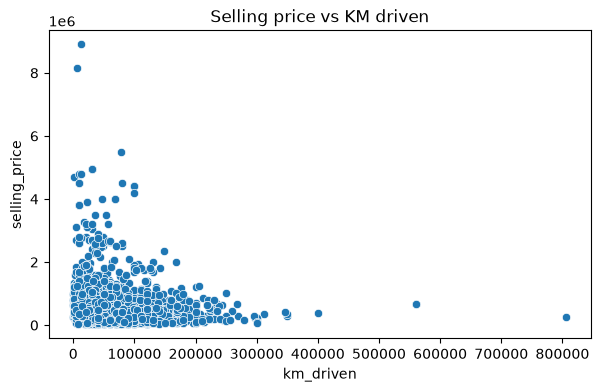

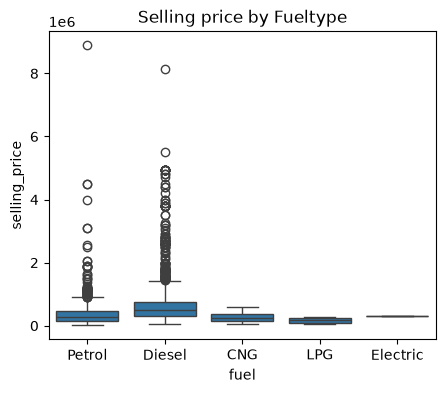

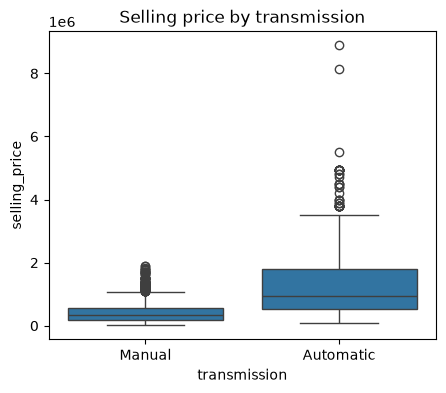

In [8]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df,x="km_driven",y="selling_price")
plt.title("Selling price vs KM driven")
plt.show()
plt.figure(figsize=(5,4))
sns.boxplot(data=df,x="fuel",y="selling_price")
plt.title("Selling price by Fueltype")
plt.show()
plt.figure(figsize=(5,4))
sns.boxplot(data=df,x="transmission",y="selling_price")
plt.title("Selling price by transmission")
plt.show()

OUTLIER ANALYSIS
Extreme values were not blindly deleted because high-priced vehicles and highly driven vehicles can be legitimate observations in a used-car market.

PREPROCESSING

There are no missing values in the dataset as the output of df.isnull().sum() is 0 and need to remove duplicates.

In [9]:
#We need to handle the 763 duplicate rows
df=df.drop_duplicates()
print(df.shape)

(3577, 8)


CREATE NEW FEATURE "vehicle_age" INSTEAD OF DEPENDING ON "year", so it becomes easy for the model.

In [10]:
df["vehicle_age"]=df["year"].max()-df["year"]
df.drop("year",axis=1,inplace=True)
print(df.head())

                       name  selling_price  km_driven    fuel seller_type  \
0             Maruti 800 AC          60000      70000  Petrol  Individual   
1  Maruti Wagon R LXI Minor         135000      50000  Petrol  Individual   
2      Hyundai Verna 1.6 SX         600000     100000  Diesel  Individual   
3    Datsun RediGO T Option         250000      46000  Petrol  Individual   
4     Honda Amaze VX i-DTEC         450000     141000  Diesel  Individual   

  transmission         owner  vehicle_age  
0       Manual   First Owner           13  
1       Manual   First Owner           13  
2       Manual   First Owner            8  
3       Manual   First Owner            3  
4       Manual  Second Owner            6  


SPLIT THE DATA INTO TRAINING AND TESTING SETS

In [11]:
x=df.drop("selling_price",axis=1)
y=df["selling_price"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

ENCODE CATEGORICAL COLUMNS INTO NUMERICAL

In [12]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
categorical_features=["name","fuel","seller_type","transmission","owner"]
numerical_features=["km_driven","vehicle_age"]
preprocessor=ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore",min_frequency=2),categorical_features),("num", StandardScaler(),
         numerical_features)
])

ColumnTransformer allows us to perform different preprocessing on different Features/Columns which means onehot encoding for categorical features and Standartscaler for numerical features.

Transforming the Input features using preprocessor;
fit- learns the parameters, transform-transforms the data based the learned parameters;
using only transform on test data prevents data leakage.

In [13]:
x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)

MODEL BUILDING

In [14]:
#Import the regression models
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor

In [15]:
#Create the models
linear_reg=LinearRegression()
ridge_reg=Ridge(alpha=10)
random_forest=RandomForestRegressor(n_estimators=100,random_state=42)
extra_tree=ExtraTreesRegressor(n_estimators=100,random_state=42)

TRAIN ALL THE REGRESSION MODELS

In [16]:
linear_reg.fit(x_train_processed,y_train)
ridge_reg.fit(x_train_processed,y_train)
random_forest.fit(x_train_processed,y_train)
extra_tree.fit(x_train_processed,y_train)

ExtraTreesRegressor(random_state=42)

MAKE PREDICTIONS WITH THE REGRESSION MODELS USING x_test_processed

In [17]:
y_pred_linear_reg=linear_reg.predict(x_test_processed)
y_pred_ridge_reg=ridge_reg.predict(x_test_processed)
y_pred_random_forest=random_forest.predict(x_test_processed)
y_pred_extra_tree=extra_tree.predict(x_test_processed)

EVALUATE THE MODELS

In [18]:
#Import the metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [19]:
print("LinearRegression")
print("MAE :",mean_absolute_error(y_test,y_pred_linear_reg))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_linear_reg)))
print("R²  :",r2_score(y_test,y_pred_linear_reg))
print("\n")
print("Ridge Regression")
print("MAE :",mean_absolute_error(y_test,y_pred_ridge_reg))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_ridge_reg)))
print("R²  :",r2_score(y_test,y_pred_ridge_reg))
print("\n")
print("Random Forest")
print("MAE :",mean_absolute_error(y_test,y_pred_random_forest))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_random_forest)))
print("R²  :",r2_score(y_test,y_pred_random_forest))
print("\n")
print("Extra Trees")
print("MAE :",mean_absolute_error(y_test,y_pred_extra_tree))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_extra_tree)))
print("R²  :",r2_score(y_test,y_pred_extra_tree))
print("\n")

LinearRegression
MAE : 176969.24158866363
RMSE: 407944.1231357759
R²  : 0.48338659975084497


Ridge Regression
MAE : 193559.0368890798
RMSE: 427973.05076051946
R²  : 0.4314127065092527


Random Forest
MAE : 157505.1382353876
RMSE: 399512.7128312304
R²  : 0.5045207039725316


Extra Trees
MAE : 159949.30244040966
RMSE: 424944.2488285368
R²  : 0.4394321106744635




IMPORTANT NOTE:
HERE BY OBSERVING "The models were compared using MAE, RMSE, and R². RANDOM FOREST achieved the best initial performance.


HYPER PARAMETER TUNING

By observing the metric values of all the models we can say that Random forest is performing better.
So tune the parameters of Random forest regressor.

In [20]:
#Import required libraries
from sklearn.model_selection import RandomizedSearchCV

In [21]:
#define Random forest models
rf=RandomForestRegressor(random_state=42)

In [22]:
#Give hyperparameter search space
param_grid={"n_estimators":[100,200,300,500],"max_depth":[None,10,20,30,40],"min_samples_split":[2,5,10],"min_samples_leaf":[1,2,4],"max_features":[1.0,"sqrt","log2"],"bootstrap":[True,False]
}

Randomized search CV randomly tests the combinations

In [23]:
#Create randomized search cross validation
random_search=RandomizedSearchCV(estimator=rf,param_distributions=param_grid,n_iter=30,cv=5,scoring="neg_mean_squared_error",random_state=42,n_jobs=-1
)

In [24]:
#Perform the tuning
random_search.fit(x_train_processed,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': [1.0, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_mean_squared_error')

best_params_ find the best performing parameteres among the given parameter grid.

In [25]:
#Find best parameters
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}


best_rf is your tuned Random forest model with its best parameters.

In [26]:
#Get the extra trees model
best_rf=random_search.best_estimator_

In [27]:
#Predict using the tuned model
y_pred_rf_tuned=best_rf.predict(x_test_processed)

In [30]:
#Evaluate the tuned model
print("Tuned Random Forest")
print("MAE :",mean_absolute_error(y_test,y_pred_rf_tuned))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_rf_tuned)))
print("R²  :",r2_score(y_test,y_pred_rf_tuned))

Tuned Random Forest
MAE : 165493.22205270152
RMSE: 397433.7620384222
R²  : 0.5096639543768136


Random Forest
MAE : 157505.1382353876
RMSE: 399512.7128312304
R²  : 0.5045207039725316

Tuned Random Forest
MAE : 165493.22205270152
RMSE: 397433.7620384222
R²  : 0.5096639543768136

IMPORTANT NOTE (P VALUE):
A p-value tells you whether a statistical relationship is significant under a particular hypothesis test. A higher R² indicates better model explanatory performance, while a lower p-value indicates stronger statistical evidence for the tested relationship.
BUT, RANDOM FOREST is a non-parametric ensemble model, so it doesn't naturally provide coefficient p-values like ordinary linear regression.

So, it is not possible to calculate p-value for RANDOM FOREST.

SAMPLE PREDICTION USING UNSEEN DATA

In [29]:
new_car=pd.DataFrame({
    "name":["Volvo V40 D3 R Design"],
    "fuel":["Diesel"],
    "seller_type":["Individual"],
    "transmission":["Automatic"],
    "owner":["First Owner"],
    "km_driven":[30000],
    "vehicle_age":[2]
})

#Apply the same preprocessing used during training
new_car_processed=preprocessor.transform(new_car)

#Predict using tuned Extra Trees model
predicted_price=best_rf.predict(new_car_processed)

print("Predicted Selling Price:",round(predicted_price[0],2))

Predicted Selling Price: 2007942.03
